In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

# Reproducibility
np.random.seed(42)

## 1. Generate Baseline Sample



In [3]:
n_treatment = 500
n_control = 500
n = n_treatment + n_control

# Group assignment
assignment = np.array([1] * n_treatment + [0] * n_control)

# Business characteristics (randomly assign)
business_type = np.random.choice(['Freelancer', 'SME'], size=n, p=[0.65, 0.35])
industry = np.random.choice(
    ['Software', 'Design', 'Consulting', 'E-commerce', 'Marketing'],
    size=n
)

# Baseline monthly foreign revenue (siulated with log-normal distribution)
baseline_revenue = np.random.lognormal(mean=6.8, sigma=0.8, size=n)


## 2. Simulate Treatment Effects

In [4]:
# Control group: modest organic growth
control_growth = np.random.normal(loc=0.03, scale=0.08, size=n)

# Treatment group: app-driven growth
# Average treatment effect ~15%
treatment_effect = 0.15
extra_growth = assignment * np.random.normal(loc=treatment_effect, scale=0.05, size=n)

# Final revenue
endline_revenue = baseline_revenue * (1 + control_growth + extra_growth)
endline_revenue = np.maximum(endline_revenue, 0)

## 3. Build Dataframe

In [5]:
df = pd.DataFrame({
    'treatment': assignment,
    'group': np.where(assignment == 1, 'Treatment', 'Control'),
    'business_type': business_type,
    'industry': industry,
    'baseline_revenue': baseline_revenue,
    'endline_revenue': endline_revenue
})

df['revenue_change'] = df['endline_revenue'] - df['baseline_revenue']
df['pct_change'] = df['revenue_change'] / df['baseline_revenue']

## 4. Summary Statistics

In [6]:
summary = df.groupby('group')[['baseline_revenue', 'endline_revenue', 'revenue_change', 'pct_change']].mean()
print("Summary Statistics by Group")
print(summary)

Summary Statistics by Group
           baseline_revenue  endline_revenue  revenue_change  pct_change
group                                                                   
Control         1331.295809      1365.015671       33.719862    0.023667
Treatment       1260.723415      1508.514616      247.791201    0.189752


## 5. Hypothesis Tests

In [7]:
treatment_changes = df[df['treatment'] == 1]['revenue_change']
control_changes = df[df['treatment'] == 0]['revenue_change']

t_stat, p_value = stats.ttest_ind(treatment_changes, control_changes, equal_var=False)
print(f"\nTwo-sample t-test on revenue change:")
print(f"t-statistic = {t_stat:.3f}")
print(f"p-value     = {p_value:.6f}")


Two-sample t-test on revenue change:
t-statistic = 14.047
p-value     = 0.000000


## 6. Regression (ITT Estimate)

In [8]:
model = smf.ols(
    'endline_revenue ~ treatment + baseline_revenue + C(business_type) + C(industry)',
    data=df
).fit(cov_type='HC3')

print("\nRegression Results")
print(model.summary())


Regression Results
                            OLS Regression Results                            
Dep. Variable:        endline_revenue   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     694.2
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        17:58:52   Log-Likelihood:                -6710.1
No. Observations:                1000   AIC:                         1.344e+04
Df Residuals:                     992   BIC:                         1.348e+04
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
In

## 7. Visualization: Mean Revenue Before vs After

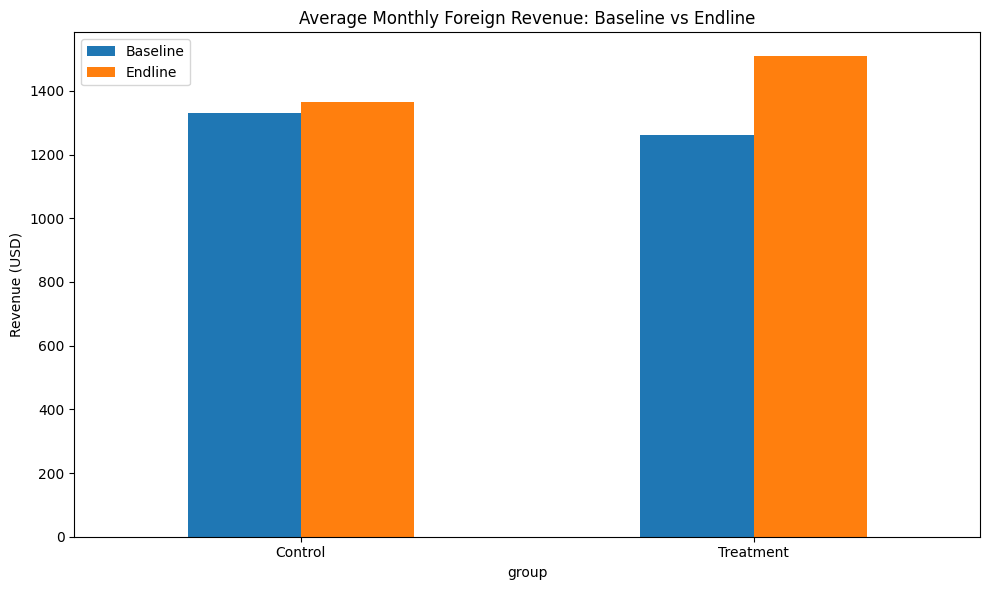

In [9]:
means = df.groupby('group')[['baseline_revenue', 'endline_revenue']].mean()

ax = means.plot(kind='bar', figsize=(10, 6))
plt.title('Average Monthly Foreign Revenue: Baseline vs Endline')
plt.ylabel('Revenue (USD)')
plt.xticks(rotation=0)
plt.legend(['Baseline', 'Endline'])
plt.tight_layout()
plt.show()

## 8. Revenue Distribution at Endline

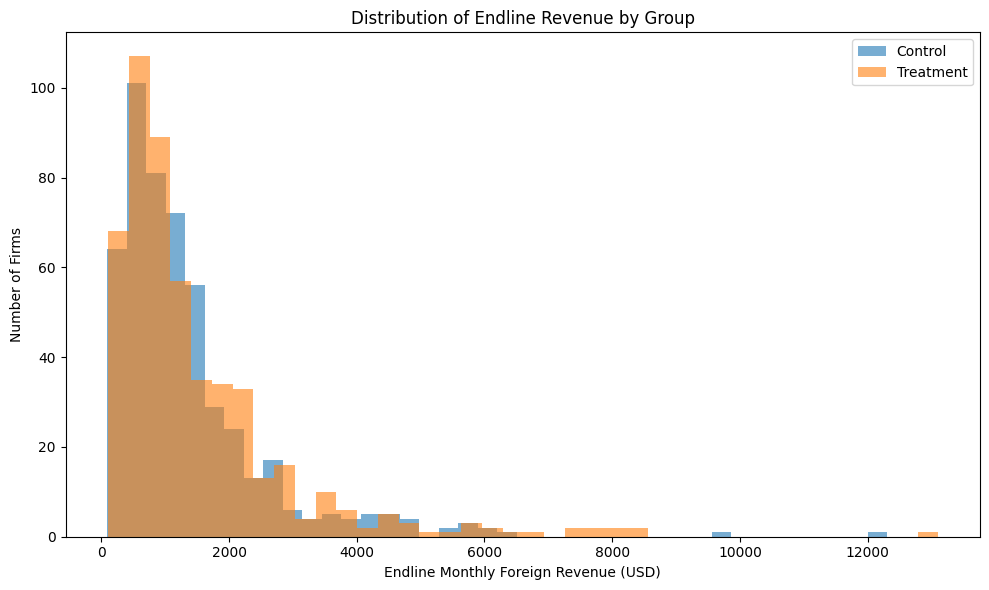

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(df[df['group'] == 'Control']['endline_revenue'], bins=40, alpha=0.6, label='Control')
plt.hist(df[df['group'] == 'Treatment']['endline_revenue'], bins=40, alpha=0.6, label='Treatment')
plt.xlabel('Endline Monthly Foreign Revenue (USD)')
plt.ylabel('Number of Firms')
plt.title('Distribution of Endline Revenue by Group')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Visualization: Revenue Change Distribution

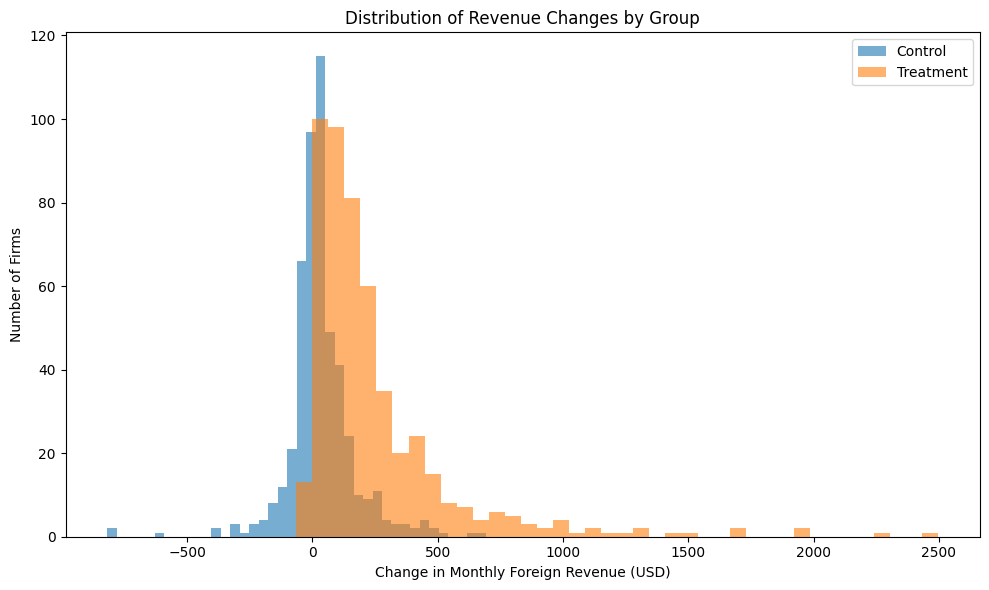

In [11]:
plt.figure(figsize=(10, 6))
plt.hist(df[df['group'] == 'Control']['revenue_change'], bins=40, alpha=0.6, label='Control')
plt.hist(df[df['group'] == 'Treatment']['revenue_change'], bins=40, alpha=0.6, label='Treatment')
plt.xlabel('Change in Monthly Foreign Revenue (USD)')
plt.ylabel('Number of Firms')
plt.title('Distribution of Revenue Changes by Group')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Percentage Change Boxplot

<Figure size 800x600 with 0 Axes>

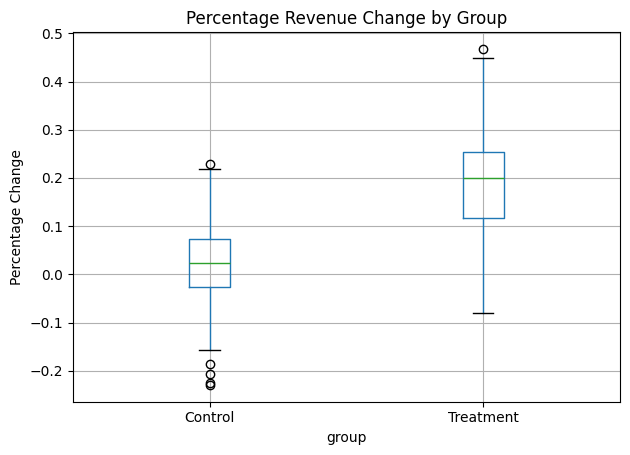

In [12]:
plt.figure(figsize=(8, 6))
df.boxplot(column='pct_change', by='group')
plt.title('Percentage Revenue Change by Group')
plt.suptitle('')
plt.ylabel('Percentage Change')
plt.tight_layout()
plt.show()

## Key Findings

In [13]:
avg_treatment_growth = df[df['treatment'] == 1]['pct_change'].mean() * 100
avg_control_growth = df[df['treatment'] == 0]['pct_change'].mean() * 100

print("\nKey Findings")
print(f"Average revenue growth (Treatment): {avg_treatment_growth:.2f}%")
print(f"Average revenue growth (Control):   {avg_control_growth:.2f}%")
print(f"Estimated treatment effect:        {(avg_treatment_growth - avg_control_growth):.2f} percentage points")

if p_value < 0.05:
    print("Result: The treatment effect is statistically significant at the 5% level.")
else:
    print("Result: The treatment effect is not statistically significant at the 5% level.")



Key Findings
Average revenue growth (Treatment): 18.98%
Average revenue growth (Control):   2.37%
Estimated treatment effect:        16.61 percentage points
Result: The treatment effect is statistically significant at the 5% level.
